# Laboratorio: One-Class SVM RBF sobre métricas de software (KC1)

**Dataset:** [PROMISE / NASA KC1](https://www.openml.org/d/1067) — métricas estáticas de módulos de código (LOC, complejidad, acoplamiento, etc.). Cada fila es un **módulo**, no un instante temporal.

**Escenario AIOps / ingeniería de software:** el “normal” son módulos históricamente **sin defectos**; el OCSVM aprende esa región en **R{21}$** (21 features) y marca módulos **atípicos** para priorizar revisión o pruebas.

Flujo pedagógico:

1. explorar métricas tabulares y correlaciones,
2. entrenar solo con módulos sin defecto (`defects=false`),
3. puntuar todos los módulos y comparar con la etiqueta real,
4. visualizar frontera RBF en 2D (`loc` vs `branchCount`),
5. sensibilidad a `nu` y `gamma`.


## 0. Dependencias

Requiere conexión a internet la primera vez (`fetch_openml`).


In [1]:
# %pip install scikit-learn pandas matplotlib


## 1. Imports


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
NU = 0.15  # ~fracción de módulos sin defecto que pueden quedar fuera (ver distribución real ~15% defectuosos)
rng = np.random.default_rng(RANDOM_STATE)
plt.style.use("default")


## 2. Cargar KC1 (métricas de software)

21 métricas por módulo (Halstead, complejidad ciclomática `v(g)`, LOC, acoplamiento, etc.) y variable objetivo `defects` (`true` / `false`).

Usamos la etiqueta **solo para evaluar**, no para entrenar el OCSVM.


In [3]:
kc1 = fetch_openml(data_id=1067, as_frame=True, parser="auto")
X_df = kc1.data.astype(float)
y = kc1.target.astype(str)

print("Módulos:", len(X_df), "| Features:", X_df.shape[1])
print(y.value_counts())
print()
X_df.describe().T.head(10)


Módulos: 2109 | Features: 21
defects
false    1783
true      326
Name: count, dtype: int64



,count,mean,std,min,25%,50%,75%,max
loc,2109.0,20.372262,29.754442,1.0,3.00,9.00,24.00,288.00
v(g),2109.0,2.838028,3.900763,1.0,1.00,1.00,3.00,45.00
ev(g),2109.0,1.674443,2.200659,1.0,1.00,1.00,1.00,26.00
iv(g),2109.0,2.546420,3.375859,1.0,1.00,1.00,3.00,45.00
n,2109.0,49.829445,83.599874,0.0,4.00,16.00,58.00,1106.00
v,2109.0,258.696719,516.317605,0.0,8.00,57.06,265.93,7918.82
l,2109.0,0.319583,0.317029,0.0,0.08,0.20,0.67,2.00
d,2109.0,6.771242,7.863646,0.0,1.50,3.50,9.20,53.75
i,2109.0,21.240071,21.500367,0.0,5.33,14.40,29.85,193.06
e,2109.0,5242.386240,17444.981211,0.0,12.00,213.97,2276.02,324803.51


### Diccionario de features (KC1 / OpenML)

Cada fila es un **módulo de código**; las columnas son métricas estáticas (McCabe, Halstead y LOC). Muchas están correlacionadas: un módulo grande suele tener LOC alto, más operadores y más ramas.

| Feature | Significado |
|---------|-------------|
| `loc` | Líneas de código del módulo |
| `v(g)` | Complejidad ciclomática (ramas / caminos en el flujo de control) |
| `ev(g)` | Complejidad ciclomática esencial |
| `iv(g)` | Complejidad de diseño del módulo |
| `branchCount` | Cantidad de ramas (if, while, switch, …) |
| `n` | Vocabulario Halstead (operadores únicos + operandos únicos) |
| `v` | Volumen Halstead |
| `l` | Longitud del programa (total operadores + operandos) |
| `d` | Dificultad Halstead |
| `i` | Contenido de inteligencia (esfuerzo mental estimado) |
| `e` | Esfuerzo de implementación estimado |
| `b` | Bugs estimados (heurística Halstead, no conteo real) |
| `t` | Tiempo estimado de programación (heurística) |
| `lOCode` | Líneas de código sin comentarios ni blancos |
| `lOComment` | Líneas de comentarios |
| `lOBlank` | Líneas en blanco |
| `locCodeAndComment` | LOC código + comentarios |
| `uniq_Op` | Operadores distintos |
| `uniq_Opnd` | Operandos distintos |
| `total_Op` | Total de operadores |
| `total_Opnd` | Total de operandos |

**Etiqueta** `defects`: `false` = sin defecto reportado; `true` = con defecto. En este laboratorio **no** entra al entrenamiento del OCSVM; solo sirve para evaluar si las anomalías coinciden con defectos históricos.

Referencia: [OpenML KC1 (id 1067)](https://www.openml.org/d/1067).


## 3. Vista tabular: correlación entre métricas

Patrones lineales fuertes (p. ej. LOC vs volumen) son normales en métricas de código. El OCSVM busca **combinaciones** que se salen del bulk de módulos sanos.


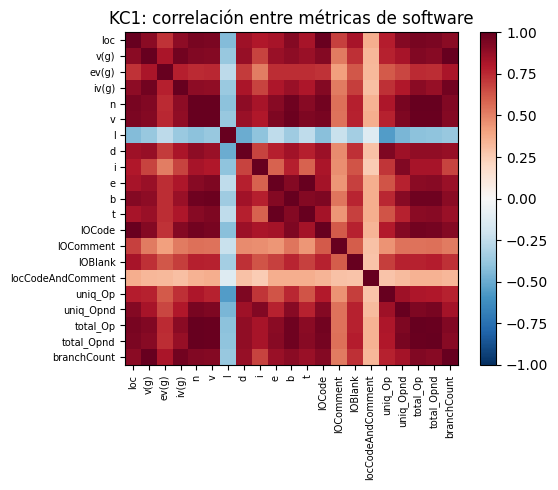

In [4]:
feature_cols = list(X_df.columns)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(X_df.corr(), cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(feature_cols)), feature_cols, rotation=90, fontsize=7)
ax.set_yticks(range(len(feature_cols)), feature_cols, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("KC1: correlación entre métricas de software")
plt.tight_layout()
plt.show()


## 4. Entrenamiento “solo normal” (one-class)

Convención: módulos con `defects=false` definen el comportamiento habitual del repositorio.

- Estandarizamos con media/desvío **solo de esos módulos**.
- `nu` controla qué fracción del train normal puede quedar fuera de la frontera (upper bound de sklearn).


In [5]:
normal_mask = y == "false"
defect_mask = y == "true"

X = X_df.to_numpy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X[normal_mask])
X_scaled_all = scaler.transform(X)

model = OneClassSVM(kernel="rbf", nu=NU, gamma="scale")
model.fit(X_scaled)

decision = model.decision_function(X_scaled_all)
pred = model.predict(X_scaled_all)

results = X_df.copy()
results["defects"] = y.values
results["decision_function"] = decision
results["anomaly_score"] = -decision
results["is_anomaly"] = pred == -1

print(f"Entrenados con {normal_mask.sum()} módulos sin defecto")
print(f"Marcados como anómalos (predict -1): {results['is_anomaly'].sum()} ({results['is_anomaly'].mean():.1%})")
print(f"Defectos reales en dataset: {defect_mask.sum()} ({defect_mask.mean():.1%})")


Entrenados con 1783 módulos sin defecto
Marcados como anómalos (predict -1): 428 (20.3%)
Defectos reales en dataset: 326 (15.5%)


## 5. ¿Detecta módulos con defectos? (evaluación)

No supervisado en entrenamiento, pero podemos medir **utilidad** contra la etiqueta histórica.


In [6]:
y_true = defect_mask.to_numpy()
y_pred = results["is_anomaly"].to_numpy()

print("Matriz de confusión (filas = defecto real, cols = OCSVM anómalo):")
print(confusion_matrix(y_true, y_pred, labels=[True, False]))
print()
print(classification_report(y_true, y_pred, target_names=["sin_defecto", "con_defecto"], zero_division=0))


Matriz de confusión (filas = defecto real, cols = OCSVM anómalo):
[[ 144  182]
 [ 284 1499]]

              precision    recall  f1-score   support

 sin_defecto       0.89      0.84      0.87      1783
 con_defecto       0.34      0.44      0.38       326

    accuracy                           0.78      2109
   macro avg       0.61      0.64      0.62      2109
weighted avg       0.81      0.78      0.79      2109



## 6. Ranking: top módulos anómalos

Revisar métricas concretas en los casos con mayor `anomaly_score`.


In [7]:
show_cols = [
    "defects", "anomaly_score", "decision_function",
    "loc", "v(g)", "ev(g)", "branchCount", "total_Opnd",
]
results.sort_values("anomaly_score", ascending=False).head(12)[show_cols]


,defects,anomaly_score,decision_function,loc,v(g),ev(g),branchCount,total_Opnd
286,true,53.323831,-53.323831,288.0,45.0,7.0,89.0,285.0
128,true,53.323831,-53.323831,286.0,27.0,5.0,53.0,171.0
299,true,53.323828,-53.323828,220.0,12.0,8.0,23.0,190.0
247,true,53.323820,-53.323820,145.0,25.0,21.0,49.0,173.0
309,true,53.315632,-53.315632,162.0,17.0,12.0,33.0,130.0
172,true,53.287441,-53.287441,184.0,16.0,12.0,31.0,180.0
237,true,53.276172,-53.276172,217.0,28.0,18.0,54.0,176.0
269,true,53.246674,-53.246674,176.0,16.0,10.0,31.0,156.0
315,true,53.208835,-53.208835,153.0,27.0,15.0,53.0,212.0
156,true,53.206595,-53.206595,62.0,14.0,1.0,36.0,163.0


## 7. Frontera RBF en 2D: `loc` vs `branchCount`

El modelo **real** usa 21 features; no se puede dibujar en un plano. Proyectamos a dos ejes y entrenamos un OCSVM **auxiliar 2D** solo para el **fondo**.

**Por qué este par:** entre pares interpretables, `loc` + `branchCount` tiene ~**90%** de acuerdo con el OCSVM 21D (igual que `loc` + `v(g)`) y AUC ligeramente mayor para defectos reales (~0.62). Alternativa con **más** separación visual: `d` + `i` (Halstead, AUC ~0.74), pero solo ~88% de acuerdo con el modelo de 21 features.

| Elemento | Significado |
|----------|-------------|
| Fondo | Frontera del OCSVM **2D auxiliar** |
| Punto **gris** | Modelo **real 21D**: normal |
| Punto **rojo** | Modelo **real 21D**: anomalía |
| **Borde negro** | Defecto histórico real (`defects=true`) |


C:\Users\Administrador\AppData\Local\Temp\ipykernel_18448\3168004925.py:24: UserWarning: The following kwargs were not used by contour: 'label'
  ax.contour(xx, yy, zz, levels=[0], colors="tab:red", linewidths=2, label="frontera OCSVM 2D (auxiliar)")


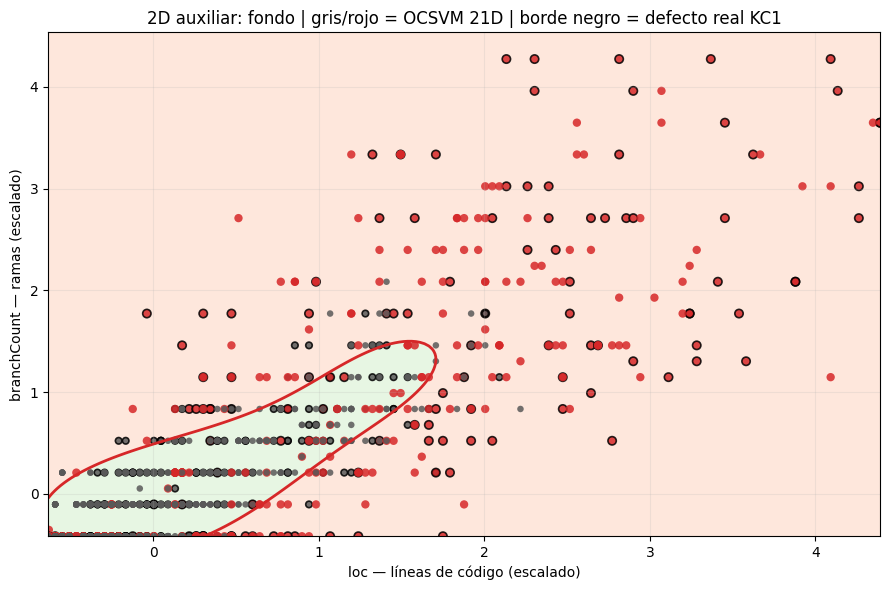

In [8]:
# Proyección 2D solo para DIBUJAR (el modelo real usa 21 features)
viz_cols = ["loc", "branchCount"]  # mejor acuerdo con OCSVM 21D que loc+v(g)
viz_idx = [feature_cols.index(c) for c in viz_cols]
X_viz = X_scaled_all[:, viz_idx]  # todos los módulos en el plano 2D elegido

# OCSVM auxiliar 2D: entrenado como el principal, solo con módulos sin defecto
viz_model = OneClassSVM(kernel="rbf", nu=NU, gamma="scale")
viz_model.fit(X_scaled[:, viz_idx])  # X_scaled = filas normales únicamente

x_lo, x_hi = np.percentile(X_viz[:, 0], [2, 98])
y_lo, y_hi = np.percentile(X_viz[:, 1], [2, 98])
xx, yy = np.meshgrid(np.linspace(x_lo, x_hi, 200), np.linspace(y_lo, y_hi, 200))
zz = viz_model.decision_function(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

# Color del punto = decisión del MODELO REAL (21D), no del auxiliar 2D
inside_main = results["decision_function"] >= 0
point_colors = np.where(inside_main, "0.35", "tab:red")
point_sizes = np.where(inside_main, 22, 36)
edge_colors = np.where(results["defects"] == "true", "black", "none")
edge_widths = np.where(results["defects"] == "true", 1.2, 0.0)

fig, ax = plt.subplots(figsize=(9, 6))
ax.contourf(xx, yy, zz, levels=[zz.min(), 0, zz.max()], colors=["#fee5d9", "#e5f5e0"], alpha=0.9)
ax.contour(xx, yy, zz, levels=[0], colors="tab:red", linewidths=2, label="frontera OCSVM 2D (auxiliar)")
ax.scatter(
    X_viz[:, 0], X_viz[:, 1], c=point_colors, s=point_sizes,
    edgecolors=edge_colors, linewidths=edge_widths, alpha=0.85,
)
ax.set_xlim(x_lo, x_hi)
ax.set_ylim(y_lo, y_hi)
ax.set_xlabel("loc — líneas de código (escalado)")
ax.set_ylabel("branchCount — ramas (escalado)")
ax.set_title("2D auxiliar: fondo | gris/rojo = OCSVM 21D | borde negro = defecto real KC1")
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()


## 8. Barras: captura de defectos vs falsas alarmas


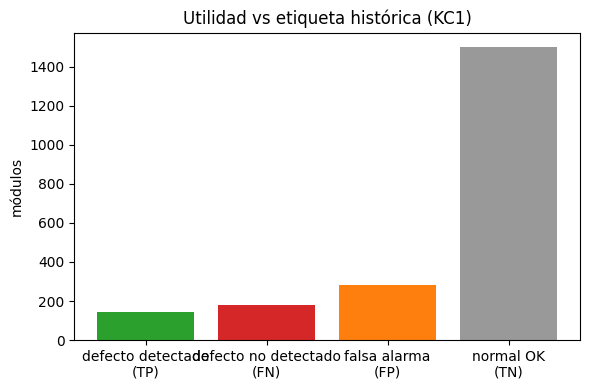

In [9]:
cm = confusion_matrix(y_true, y_pred)  # filas: sin defecto (0), con defecto (1)
tn, fp, fn, tp = cm[0, 0], cm[0, 1], cm[1, 0], cm[1, 1]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(
    ["defecto detectado\n(TP)", "defecto no detectado\n(FN)", "falsa alarma\n(FP)", "normal OK\n(TN)"],
    [tp, fn, fp, tn],
    color=["tab:green", "tab:red", "tab:orange", "0.6"],
)
ax.set_title("Utilidad vs etiqueta histórica (KC1)")
ax.set_ylabel("módulos")
plt.tight_layout()
plt.show()


## 9. Sensibilidad a `nu`


In [10]:
nu_grid = [0.05, 0.10, 0.15, 0.20, 0.25]
rows = []
for nu_c in nu_grid:
    m = OneClassSVM(kernel="rbf", nu=nu_c, gamma="scale")
    m.fit(X_scaled)
    pred_c = m.predict(X_scaled_all) == -1
    tp = ((pred_c) & defect_mask).sum()
    fp = ((pred_c) & normal_mask).sum()
    rows.append({"nu": nu_c, "anomalias": pred_c.sum(), "TP_defectos": int(tp), "FP_normales": int(fp)})
pd.DataFrame(rows)


,nu,anomalias,TP_defectos,FP_normales
0,0.05,178,90,88
1,0.10,292,122,170
2,0.15,428,144,284
3,0.20,518,165,353
4,0.25,620,179,441


## 10. Sensibilidad a `gamma`


In [11]:
gamma_grid = ["scale", 0.05, 0.2, 1.0]
grow = []
for g in gamma_grid:
    m = OneClassSVM(kernel="rbf", nu=NU, gamma=g)
    m.fit(X_scaled)
    pred_g = m.predict(X_scaled_all) == -1
    tp = ((pred_g) & defect_mask).sum()
    grow.append({"gamma": g, "anomalias": int(pred_g.sum()), "TP_defectos": int(tp)})
pd.DataFrame(grow)


,gamma,anomalias,TP_defectos
0,scale,428,144
1,0.05,404,143
2,0.2,450,161
3,1.0,602,220


## 11. Puente con AIOps (discusión)

| Serie temporal (KPI/minuto) | Métricas de software (KC1) |
|-----------------------------|----------------------------|
| Fila = instante | Fila = módulo / servicio / build |
| Deriva, estacionalidad | Cambio de código, deuda técnica |
| Features de ventana | Métricas de SonarQube, coverage, complejidad |

El **mismo algoritmo** (OCSVM + RBF + escalado) aplica a ambos; cambia el **dominio** y el diseño del train set (aquí: solo “sin defecto”).

**Ejercicios**

1. Cambiar `NU` y la tabla de sensibilidad: ¿qué valor maximiza TP sin explotar FP?
2. Implementar y comparar con Isolation Forest en las mismas 21 columnas.



### 1. Cambiar `NU` y la tabla de sensibilidad: ¿qué valor maximiza TP sin explotar FP?

In [ ]:

df = pd.DataFrame(rows)

df["delta_TP"] = df["TP_defectos"].diff()
df["delta_FP"] = df["FP_normales"].diff()
df["TP_por_FP_adicional"] = (
    df["delta_TP"] / df["delta_FP"]
)

df

,nu,anomalias,TP_defectos,FP_normales,delta_TP,delta_FP,TP_por_FP_adicional
0,0.05,178,90,88,NaN,NaN,NaN
1,0.10,292,122,170,32.0,82.0,0.390244
2,0.15,428,144,284,22.0,114.0,0.192982
3,0.20,518,165,353,21.0,69.0,0.304348
4,0.25,620,179,441,14.0,88.0,0.159091


Al aumentar NU el modelo detecta más defectos a costa de aumentar los FP, viendo el beneficio marginal el mayor rendimiento se ve al pasar de 0.05 a 0.1, donde por cada falso positivo adicional se detecta 0.39 verdaderos positivos, el paso a NUs mayores genera un rendimiento decreciente y un trabajo manual adicional que puede no ser sostenible dependiendo de la capacidad del equipo.

### 2. Implementar y comparar con Isolation Forest en las mismas 21 columnas.

In [ ]:

from sklearn.ensemble import IsolationForest
iso = IsolationForest(n_estimators=200, contamination=0.15, random_state=42) #contaminacion igual a NU para comparar (totalmente arbitrario tbh)
iso.fit(X_scaled)
iso_pred = iso.predict(X_scaled_all) == -1
iso_tp = ((iso_pred) & defect_mask).sum()
iso_fp = ((iso_pred) & normal_mask).sum()
iso_fn = ((~iso_pred) & defect_mask).sum()
iso_tn = ((~iso_pred) & normal_mask).sum()

pd.DataFrame([{
    "Modelo": "Isolation Forest",
    "TP": iso_tp,
    "FP": iso_fp,
    "FN": iso_fn,
    "TN": iso_tn,
    "precision": round(iso_tp / (iso_tp + iso_fp), 3) if (iso_tp + iso_fp) > 0 else 0,
    "recall": round(iso_tp / (iso_tp + iso_fn), 3) if (iso_tp + iso_fn) > 0 else 0,
}])

,Modelo,TP,FP,FN,TN,precision,recall
0,Isolation Forest,170,268,156,1515,0.388,0.521


| Modelo            | TP  | FP  | FN  | TN   | Precision | Recall |
|-------------------|-----|-----|-----|------|-----------|--------|
| One-Class SVM     | 144 | 284 | 182 | 1499 | 0.336     | 0.442  |
| Isolation Forest  | 170 | 268 | 156 | 1515 | 0.388     | 0.521  |

Usando las mismas métricas, Isolation Forest mejora tanto la precisión como el recall, detectando más defectos reales (TP) y reduciendo las falsas alarmas (FP) en comparación con el One-Class SVM. Esto sugiere que Isolation Forest es más efectivo para este conjunto de datos específico.